In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('./results/cleaned_shipment_classification_dataset.csv')

In [4]:
df['is_delayed'] = (df['delay_days'] > 5).astype(int)

In [5]:
print(df.shape)
print(df.dtypes)

(802, 28)
delay_days                  int64
shipping_duration_days      int64
lead_time_days              int64
is_early_delivery           int64
scac                       object
tariff_amount             float64
ocean_freight             float64
delivery_terms             object
po_shipment_terms          object
tariff_type                object
total_bcy                 float64
quantity_in               float64
item_sku                    int64
item_brand                 object
item_manufacturer          object
item_product_category      object
item_size                  object
vendor_name                object
vendor_avg_delay_days     float64
vendor_shipments            int64
vendor_on_time_rate       float64
vendor_p50_delay_days       int64
vendor_p90_delay_days       int64
shipped_date_weekday        int64
shipped_date_month          int64
shipped_date_day            int64
distance_nm                 int64
is_delayed                  int64
dtype: object


In [6]:
df.isnull().sum().sort_values(ascending=False)

delay_days                0
shipping_duration_days    0
lead_time_days            0
is_early_delivery         0
scac                      0
tariff_amount             0
ocean_freight             0
delivery_terms            0
po_shipment_terms         0
tariff_type               0
total_bcy                 0
quantity_in               0
item_sku                  0
item_brand                0
item_manufacturer         0
item_product_category     0
item_size                 0
vendor_name               0
vendor_avg_delay_days     0
vendor_shipments          0
vendor_on_time_rate       0
vendor_p50_delay_days     0
vendor_p90_delay_days     0
shipped_date_weekday      0
shipped_date_month        0
shipped_date_day          0
distance_nm               0
is_delayed                0
dtype: int64

In [7]:
df.describe(include='all')

,delay_days,shipping_duration_days,lead_time_days,is_early_delivery,scac,tariff_amount,ocean_freight,delivery_terms,po_shipment_terms,tariff_type,...,vendor_avg_delay_days,vendor_shipments,vendor_on_time_rate,vendor_p50_delay_days,vendor_p90_delay_days,shipped_date_weekday,shipped_date_month,shipped_date_day,distance_nm,is_delayed
count,802.000000,802.000000,802.000000,802.0,802,802.000000,802.000000,802,802,802,...,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000
unique,NaN,NaN,NaN,NaN,11,NaN,NaN,2,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,CMDU,NaN,NaN,CY,CNF,Not Applicable,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,520,NaN,NaN,700,403,614,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.256858,57.500000,97.226933,0.0,NaN,3781.870599,1311.158342,NaN,NaN,NaN,...,4.267681,188.975062,0.007120,3.400249,6.470075,3.115960,6.062344,15.597257,10252.369077,0.150873
std,5.793048,12.892841,90.435627,0.0,NaN,9236.440174,2346.276140,NaN,NaN,NaN,...,1.067481,148.174904,0.013975,0.610479,1.417644,1.908721,3.078029,8.810030,1740.793690,0.358148
min,0.000000,20.000000,13.000000,0.0,NaN,0.000000,0.000000,NaN,NaN,NaN,...,3.250000,4.000000,0.000000,3.000000,4.000000,0.000000,1.000000,1.000000,2100.000000,0.000000
25%,2.000000,51.000000,48.000000,0.0,NaN,0.000000,0.000000,NaN,NaN,NaN,...,3.780000,55.000000,0.000000,3.000000,6.000000,1.000000,3.000000,8.000000,11000.000000,0.000000
50%,3.000000,54.000000,67.000000,0.0,NaN,0.000000,0.000000,NaN,NaN,NaN,...,3.780000,96.000000,0.000000,3.000000,6.000000,3.000000,6.000000,15.000000,11000.000000,0.000000
75%,5.000000,61.000000,109.000000,0.0,NaN,0.000000,0.000000,NaN,NaN,NaN,...,4.380000,347.000000,0.010000,4.000000,6.000000,5.000000,8.000000,24.000000,11000.000000,0.000000


Text(0.5, 1.0, 'Item Product Category Distribution')

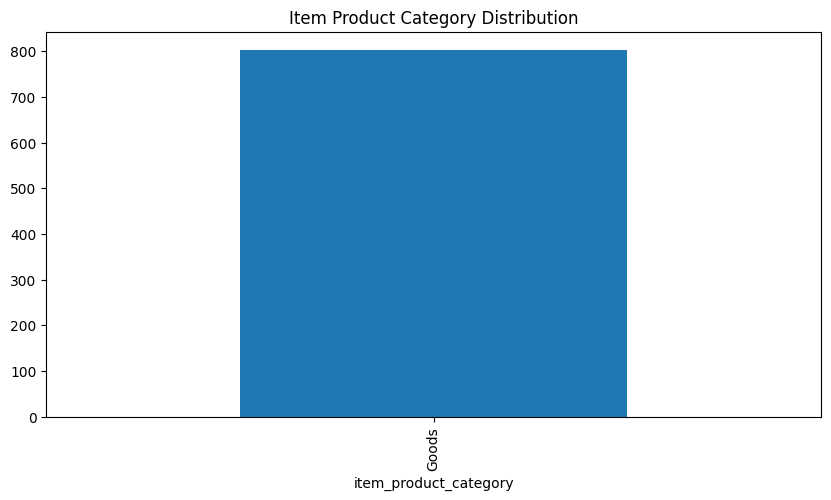

In [ ]:
# df['item_product_category'].value_counts().plot(kind='bar', figsize=(10,5))
# plt.title('Item Product Category Distribution')

Text(0.5, 1.0, 'Item Manufacturer Distribution')

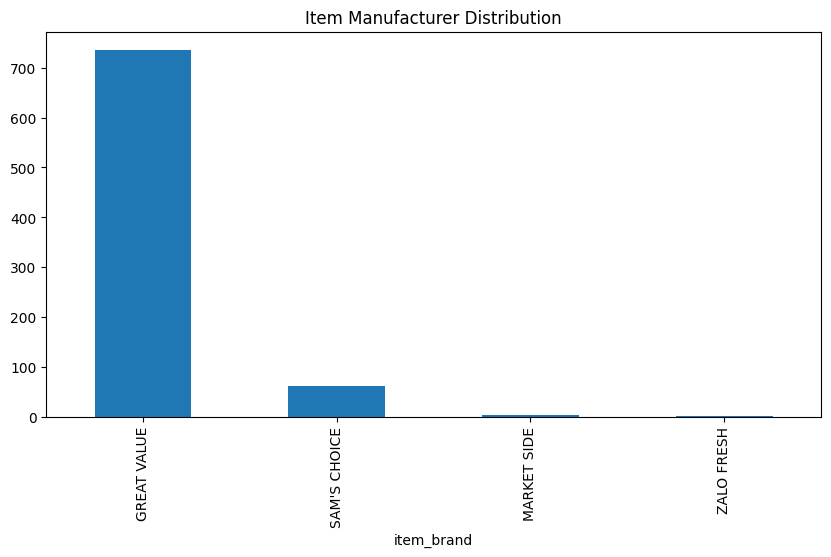

In [16]:
df['item_brand'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Item Manufacturer Distribution')

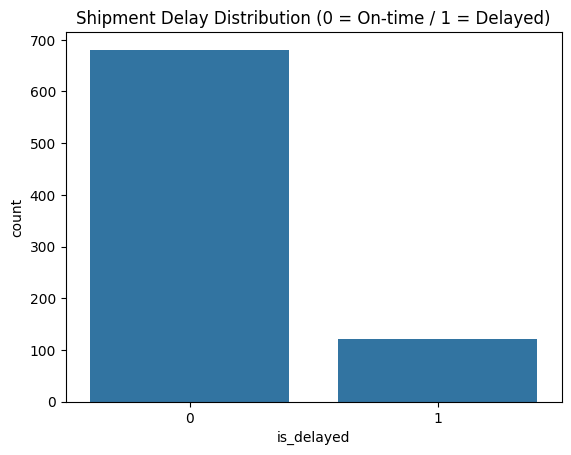

In [9]:
df['is_delayed'].value_counts(normalize=True) * 100
sns.countplot(x='is_delayed', data=df)
plt.title('Shipment Delay Distribution (0 = On-time / 1 = Delayed)')
plt.show()


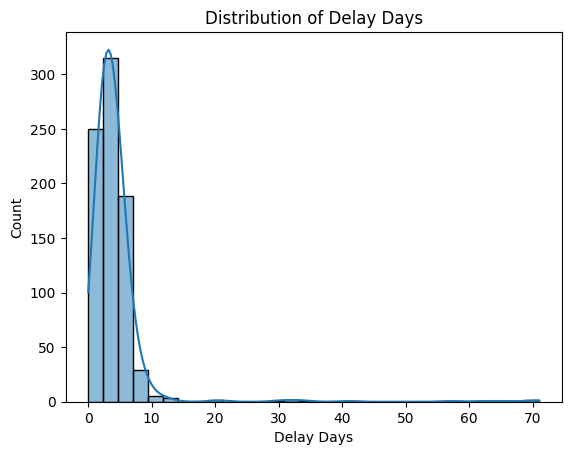

In [10]:
sns.histplot(df['delay_days'], bins=30, kde=True)
plt.title('Distribution of Delay Days')
plt.xlabel('Delay Days')
plt.show()

In [11]:
df['is_delayed'].value_counts(normalize=True)

is_delayed
0    0.849127
1    0.150873
Name: proportion, dtype: float64

In [12]:
df['delay_days'].describe()


count    802.000000
mean       4.256858
std        5.793048
min        0.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       71.000000
Name: delay_days, dtype: float64

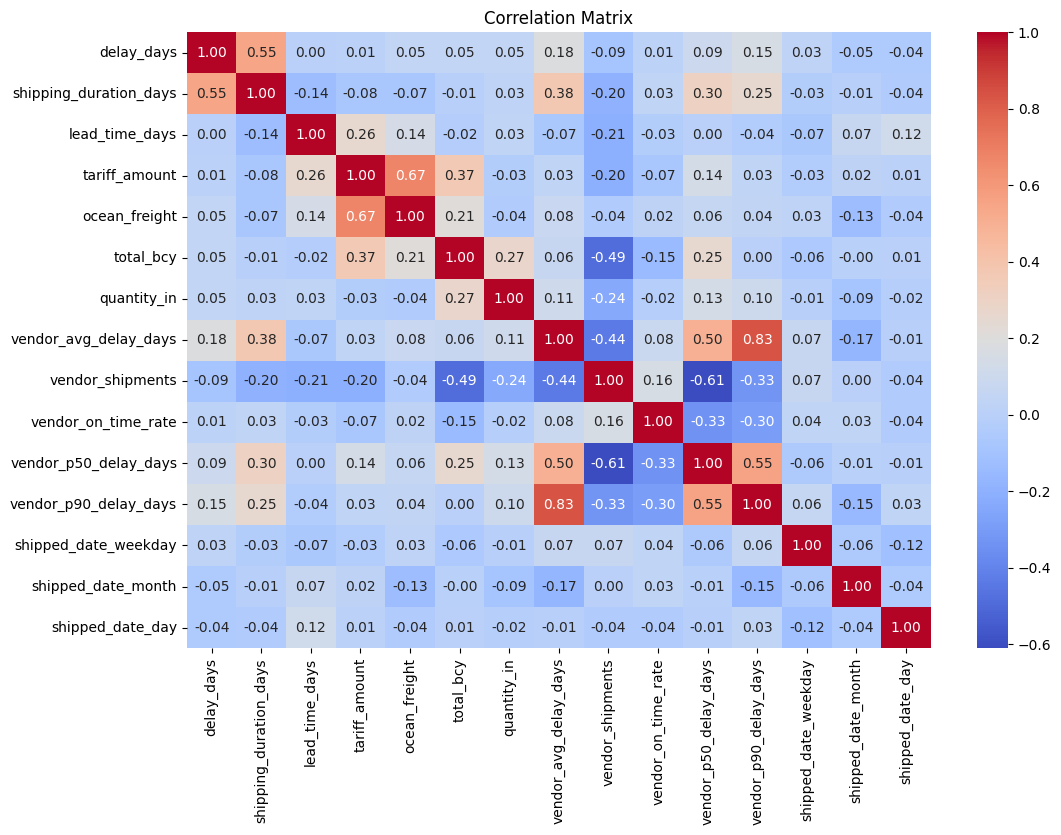

In [13]:
num_cols = [
    'delay_days', 'shipping_duration_days', 'lead_time_days',
    'tariff_amount', 'ocean_freight', 'total_bcy', 'quantity_in',
    'vendor_avg_delay_days', 'vendor_shipments', 'vendor_on_time_rate',
    'vendor_p50_delay_days', 'vendor_p90_delay_days',
    'shipped_date_weekday', 'shipped_date_month', 'shipped_date_day'
]
corr = df[num_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


In [14]:
sns.barplot(
    x='coo', y='is_delayed', data=df, estimator=np.mean, order=df['coo'].value_counts().index
)
plt.title('Delay Rate by Country of Origin')
plt.xticks(rotation=45)
plt.show()


KeyError: 'coo'

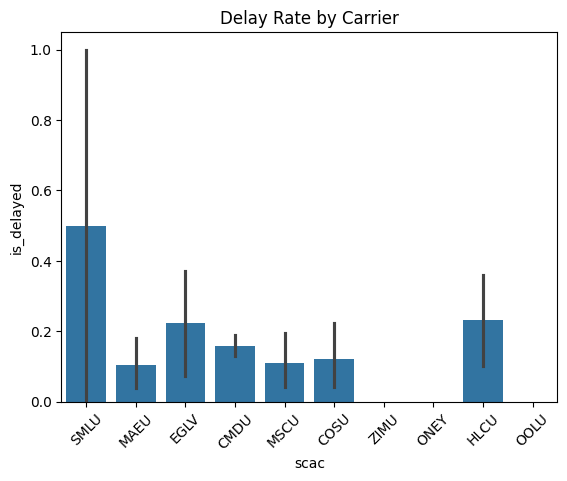

In [ ]:
top_scac = df['scac'].value_counts().index[:10]
sns.barplot(x='scac', y='is_delayed', data=df[df['scac'].isin(top_scac)], estimator=np.mean)
plt.title('Delay Rate by Carrier')
plt.xticks(rotation=45)
plt.show()


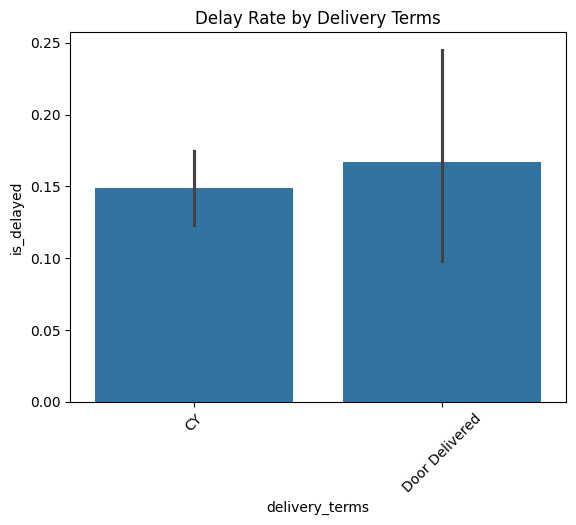

In [ ]:
sns.barplot(x='delivery_terms', y='is_delayed', data=df, estimator=np.mean)
plt.title('Delay Rate by Delivery Terms')
plt.xticks(rotation=45)
plt.show()


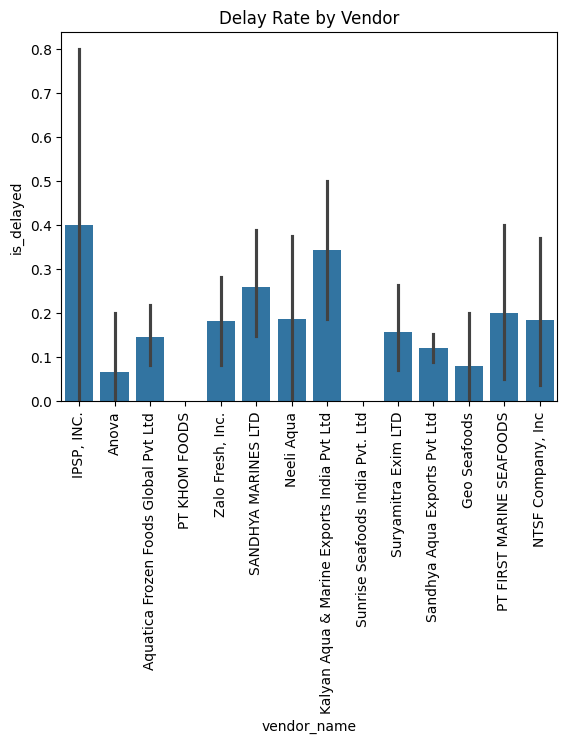

In [ ]:
top_vendors = df['vendor_name'].value_counts().index[:15]
sns.barplot(x='vendor_name', y='is_delayed', data=df[df['vendor_name'].isin(top_vendors)], estimator=np.mean)
plt.xticks(rotation=90)
plt.title('Delay Rate by Vendor')
plt.show()


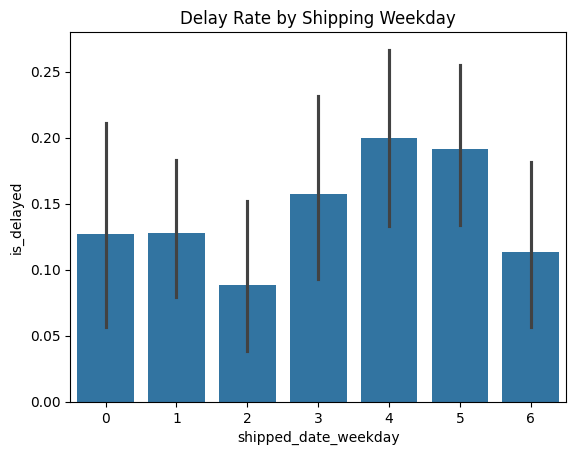

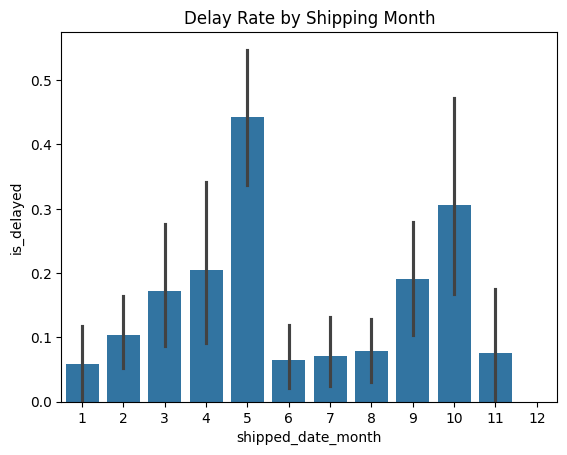

In [ ]:
sns.barplot(x='shipped_date_weekday', y='is_delayed', data=df, estimator=np.mean)
plt.title('Delay Rate by Shipping Weekday')
plt.show()

sns.barplot(x='shipped_date_month', y='is_delayed', data=df, estimator=np.mean)
plt.title('Delay Rate by Shipping Month')
plt.show()


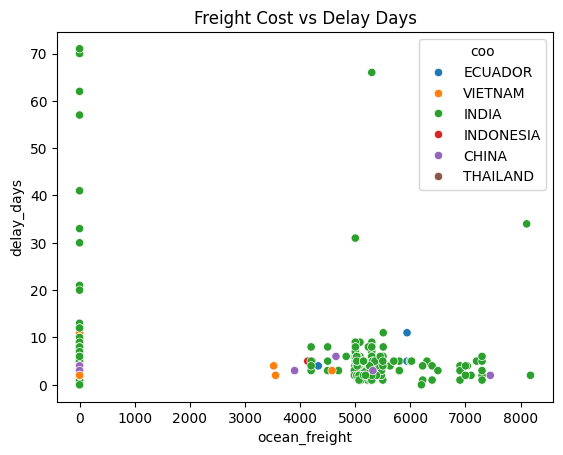

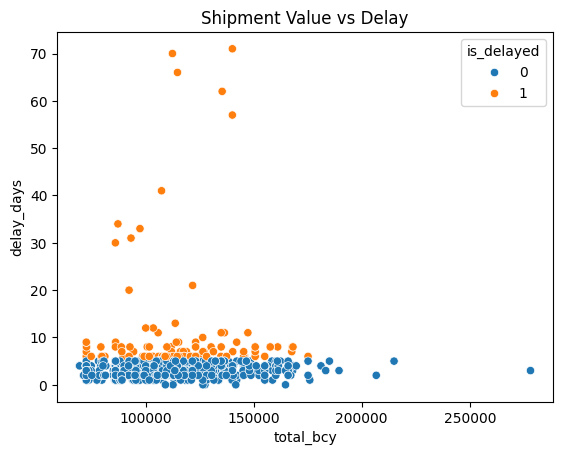

In [ ]:
sns.scatterplot(x='ocean_freight', y='delay_days', hue='coo', data=df)
plt.title('Freight Cost vs Delay Days')
plt.show()

sns.scatterplot(x='total_bcy', y='delay_days', hue='is_delayed', data=df)
plt.title('Shipment Value vs Delay')
plt.show()
